# Week 4 Data Exploration Challenge
## Welltory COVID-19 and Wearables Dataset

### 1. Dataset Context and Sampling

The Welltory COVID-19 and Wearables Open Data Research dataset was collected in 2020 to investigate patterns related to COVID-19 progression and recovery. The dataset contains health information collected from participants through the Welltory app, including heart rate variability (HRV), heart rate, sleep, blood pressure, wearable-device data, surveys, and participant information.

The data represents participating Welltory users rather than a random sample of the general population. Because of this sampling approach, this does not present the broader population.

The dataset consists of multiple related CSV files. Participants are identified using an anonymized `user_code`, which will allow us to associate the user with various other data sets. Some files, such as `participants.csv`, contain participant-level information, while measurement files such as `heart_rate.csv` can contain multiple observations for the same participant over time.

I will be exploring participants.csv to better understand the population involved in the data collection. The full participant dataset was analyzed rather than taking a smaller sample.

## 2. Load and Understand the Data

Loading/ examining data before making any cleaning and transforming decisions

In [17]:
import pandas as pd

In [18]:
participants = pd.read_csv("data/participants.csv")
participants.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


In [19]:
# Inspect dataset structure
print("Dataset shape:", participants.shape)
participants.info()

Dataset shape: (185, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB


In [20]:
# Descriptive statistics
participants.describe(include="all")

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
count,185,185,185,173,179,183.000000,185.000000,147
unique,185,2,6,116,25,NaN,NaN,74
top,007b8190cf,f,35-44,Moscow,Russia,NaN,NaN,5/6/2020
freq,1,118,56,34,66,NaN,NaN,7
mean,NaN,NaN,NaN,NaN,NaN,169.976393,77.927757,NaN
std,NaN,NaN,NaN,NaN,NaN,12.400103,19.552541,NaN
min,NaN,NaN,NaN,NaN,NaN,132.080000,43.500000,NaN
25%,NaN,NaN,NaN,NaN,NaN,163.500000,63.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,168.000000,74.344000,NaN
75%,NaN,NaN,NaN,NaN,NaN,174.500000,90.537000,NaN


In [21]:
# Check missing values and duplicate rows
print("Missing values:")
print(participants.isnull().sum())

print("\nDuplicate rows:", participants.duplicated().sum())

Missing values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64

Duplicate rows: 0


In [22]:
# Check potential outliers in height and weight
participants.sort_values("height", ascending=False)[["user_code", "height", "weight"]].head(10)

,user_code,height,weight
102,83161408c1,250.00,82.146
49,3fff7627ca,248.92,114.713
83,6ce06ce747,203.00,70.534
175,f8b552df37,193.00,90.000
136,b3c7f65a4b,193.00,65.998
112,985cf692d0,190.00,102.000
116,9b4a5ded49,189.00,89.500
25,1fa680ad84,188.00,90.000
160,e1578ff865,188.00,117.000
94,7badc26d11,187.96,97.931


### Outlier Detection

The descriptive statistics showed a maximum height of 250 cm, which appeared high compared with the rest of the dataset. I looked at the `height` variable for potential outliers using the IQR method. Values identified as outliers were investigated before deciding whether they should be removed or retained.

In [23]:
# Detect height outliers using the IQR method
Q1 = participants["height"].quantile(0.25)
Q3 = participants["height"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

height_outliers = participants[
    (participants["height"] < lower_bound) |
    (participants["height"] > upper_bound)
]

height_outliers[["user_code", "height", "weight"]]

Lower bound: 147.0
Upper bound: 191.0


,user_code,height,weight
49,3fff7627ca,248.92,114.713
65,5214210ed1,132.08,67.903
83,6ce06ce747,203.00,70.534
102,83161408c1,250.00,82.146
136,b3c7f65a4b,193.00,65.998
175,f8b552df37,193.00,90.000


### Handling Height Outliers

The IQR method identified six potential height outliers. Values between 132.08 cm and 203 cm were retained because, although statistically unusual, they are plausible human heights. The two values near 250 cm were considered likely data-quality issues because they are extremely implausible. Rather than removing the entire participant records, these height values will be treated as missing 

In [24]:
import numpy as np

# Treat implausible height values as missing
participants.loc[participants["height"] > 240, "height"] = np.nan

In [25]:
participants["height"].isnull().sum()

4

In [26]:
# Calculate missing values and percentages
missing_summary = pd.DataFrame({
    "missing_count": participants.isnull().sum(),
    "missing_percent": participants.isnull().mean() * 100
})

missing_summary

,missing_count,missing_percent
user_code,0,0.000000
gender,0,0.000000
age_range,0,0.000000
city,12,6.486486
country,6,3.243243
height,4,2.162162
weight,0,0.000000
symptoms_onset,38,20.540541


# Date Transformation

THe symptoms_onset variable is stored as an object. I convertedit to a datetime format so dates can be stored correctyl and can be used for date-based anaylsis, especially with other data sets. 

In [27]:
# Convert symptoms onset to datetime
participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"],
    errors="coerce"
)

participants.dtypes

user_code                 object
gender                    object
age_range                 object
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object

In [28]:
# Create BMI feature
participants["bmi"] = participants["weight"] / (participants["height"] / 100) ** 2

participants[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,170.18,96.162,33.203698
1,174.00,77.300,25.531774
2,178.00,92.000,29.036738
3,169.00,60.000,21.007668
4,158.00,68.500,27.439513


### Creating a new Feature - Feature Engineering

A new BMI feature was created using participant height and weight. Height was converted from centimeters to meters before calculating BMI. BMI provides a single measure that combines height and weight and can be used to explore relationships with other health variables.

## 3. Visual Exploration and Variable Relationships

The relationship between participant age range and BMI was explored to determine whether BMI distributions differ across age groups.

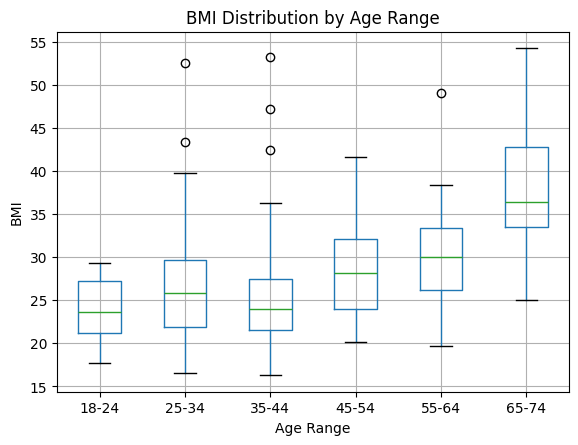

In [29]:
import matplotlib.pyplot as plt

participants.boxplot(column="bmi", by="age_range")

plt.title("BMI Distribution by Age Range")
plt.suptitle("")
plt.xlabel("Age Range")
plt.ylabel("BMI")
plt.show()

### Data Analysis 

BMI generally increases across the older age groups, with the highest median BMI observed in the 65–74 group. Several high-BMI outliers are also present in the younger age groups.

## 4. Data Quality Assessment

**Data Profiling:**  
The participants dataset contains 185 rows and originally contained 8 variables. The variables include demographic information, location, height, weight, and symptom onset date.

**Data Completeness:**  
There were missing values in city, country, height, and symptoms_onset. Symptoms_onset had the most missing data at approximately 20.5%. Missing values were retained rather than automatically removed because the reason for missingness is unknown and may differ between variables. For example, a missing symptoms_onset value could have a different meaning than a missing height or city value. These missing values could be further investigated.

**Data Accuracy:**  
Height values were examined for potential outliers as it stood out of the df.describe statistics. Two values above 240 cm were considered implausible and were converted to missing values rather than deleting the participants as their information can still be valuable.

**Data Consistency:**  
The symptoms_onset variable was originally stored as text and was converted to a datetime format so that dates are represented consistently and can be analyzed correctly. 

**Data Integrity:**  
No duplicate rows were found. The user_code variable provides an anonymized identifier for each participant and can be used to associate participant information with measurements in the other dataset files.

**Data Lineage and Provenance:**  
The data comes from the Welltory COVID-19 and Wearables Open Data Research dataset. The participants.csv file contains participant-level information and is part of a larger collection containing wearable and health measurements.